In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
train = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv")
test = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv")

In [3]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. Trích xuất dữ liệu gốc từ DataFrame
X_train_full = train.iloc[:, :-1].values
y_train_full = train.iloc[:, -1].values

X_test = test.iloc[:, :-1].values
y_test = test.iloc[:, -1].values

# 2. CHIA TẬP TRAIN THÀNH TRAIN (80%) VÀ VALIDATION (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.2, 
    stratify=y_train_full, # Rất quan trọng: Giữ nguyên tỷ lệ các loại nhịp tim
    random_state=42
)

# 3. Ép kiểu sang PyTorch Tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# 4. Thêm chiều thứ 3 (Input_size = 1) cho kiến trúc LSTM/RNN
X_train_tensor = X_train_tensor.unsqueeze(2)
X_val_tensor = X_val_tensor.unsqueeze(2)
X_test_tensor = X_test_tensor.unsqueeze(2)

# 5. Bọc vào TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 6. Tạo DataLoader
BATCH_SIZE = 64

# Chỉ Train mới cần shuffle (xáo trộn) để mô hình học tốt hơn
train_load = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# Val và Test chỉ để đánh giá, không cần shuffle
val_load = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_load = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Kiểm tra nhanh cấu trúc dữ liệu ---
for batch_X, batch_y in train_load:
    print(f"Shape của 1 cụm X_train: {batch_X.shape}") # Kỳ vọng: [64, 187, 1]
    print(f"Shape của 1 cụm y_train: {batch_y.shape}") # Kỳ vọng: [64]
    break

for batch_X, batch_y in val_load:
    print(f"Shape của 1 cụm X_val: {batch_X.shape}")   # Kỳ vọng: [64, 187, 1]
    break

Shape của 1 cụm X_train: torch.Size([64, 187, 1])
Shape của 1 cụm y_train: torch.Size([64])
Shape của 1 cụm X_val: torch.Size([64, 187, 1])


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Khởi tạo mô hình nguyên bản

class ECG_RNN(nn.Module):
    def __init__(self,input_size =1 ,hidden_size=64,num_layers=2 , num_classes=5):
        super(ECG_RNN,self).__init__()
        self.rnn = nn.RNN(input_size,hidden_size,num_layers,batch_first=True,nonlinearity = 'relu',dropout =0.2)
        self.fc = nn.Linear(hidden_size, num_classes)
    def forward(self,x):
        out,hidden = self.rnn(x)
        last_hidden =  hidden[-1,:,:]
        log = self.fc(last_hidden)
        return log
    
model = ECG_RNN(input_size=1, hidden_size=64, num_layers=2, num_classes=5)

# 2. BƯỚC QUAN TRỌNG: Kiểm tra và kích hoạt đa GPU
if torch.cuda.device_count() > 1:
    print(f"Tuyệt vời! Đang sử dụng {torch.cuda.device_count()} GPUs để huấn luyện.")
    # Chia đều công việc cho tất cả GPU hiện có
    model = nn.DataParallel(model)

# 3. Đẩy mô hình lên thiết bị
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

class_counts = np.bincount(y_train.astype(int))

smooth_weights = np.sqrt(len(y_train) / class_counts)
class_weights = smooth_weights / smooth_weights.sum() * len(class_counts)

weights_tensor = torch.tensor(
    class_weights, dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [15]:
# Train RNN và lưu checkpoint tốt nhất
EPOCHS = 15
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for batch_X, batch_y in train_load:
        batch_X = batch_X.to(device)
        batch_y = batch_y.long().to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        train_correct += (predicted == batch_y).sum().item()
        train_total += batch_y.size(0)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch_X, batch_y in val_load:
            batch_X = batch_X.to(device)
            batch_y = batch_y.long().to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            val_correct += (predicted == batch_y).sum().item()
            val_total += batch_y.size(0)

    avg_train_loss = train_loss / len(train_load)
    avg_val_loss = val_loss / len(val_load)
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train loss: {avg_train_loss:.4f}, Acc: {train_acc:.2f}% | "
        f"Val loss: {avg_val_loss:.4f}, Acc: {val_acc:.2f}%"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), "best_ecg_rnn.pth")
        else:
            torch.save(model.state_dict(), "best_ecg_rnn.pth")

        print("→ Đã lưu RNN tốt nhất")

print("Hoàn tất train RNN.")

Epoch [1/15] | Train loss: 1.2944, Acc: 82.77% | Val loss: 1.2677, Acc: 82.77%
→ Đã lưu RNN tốt nhất
Epoch [2/15] | Train loss: 1.2621, Acc: 82.75% | Val loss: 1.2499, Acc: 82.35%
→ Đã lưu RNN tốt nhất
Epoch [3/15] | Train loss: 1.2311, Acc: 82.38% | Val loss: 1.2056, Acc: 82.42%
→ Đã lưu RNN tốt nhất
Epoch [4/15] | Train loss: 1.2517, Acc: 82.22% | Val loss: 1.2214, Acc: 82.02%
Epoch [5/15] | Train loss: 1.2288, Acc: 82.27% | Val loss: 1.2276, Acc: 82.32%
Epoch [6/15] | Train loss: 1.2263, Acc: 82.35% | Val loss: 1.2181, Acc: 82.39%
Epoch [7/15] | Train loss: 1.2233, Acc: 82.29% | Val loss: 1.2125, Acc: 82.44%
Epoch [8/15] | Train loss: 1.2209, Acc: 82.38% | Val loss: 1.2102, Acc: 82.43%
Epoch [9/15] | Train loss: 1.2188, Acc: 82.43% | Val loss: 1.2101, Acc: 82.61%
Epoch [10/15] | Train loss: 1.2188, Acc: 82.48% | Val loss: 1.2084, Acc: 82.03%
Epoch [11/15] | Train loss: 1.2137, Acc: 82.43% | Val loss: 1.2133, Acc: 81.56%
Epoch [12/15] | Train loss: 1.2089, Acc: 82.34% | Val loss: 1.1

In [16]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Tải RNN tốt nhất
checkpoint = torch.load("best_ecg_rnn.pth", map_location=device)

if isinstance(model, nn.DataParallel):
    model.module.load_state_dict(checkpoint)
else:
    model.load_state_dict(checkpoint)

model.eval()

total_test_loss = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_load:
        batch_X = batch_X.to(device)
        batch_y = batch_y.long().to(device)

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        total_test_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())

test_loss = total_test_loss / len(test_load)
test_accuracy = accuracy_score(all_targets, all_preds)

print("=== KẾT QUẢ RNN TRÊN TẬP TEST ===")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print("\n=== Classification report ===")
print(classification_report(all_targets, all_preds, digits=4, zero_division=0))

=== KẾT QUẢ RNN TRÊN TẬP TEST ===
Test loss: 0.8086
Test accuracy: 82.62%

=== Classification report ===
              precision    recall  f1-score   support

           0     0.8303    0.9950    0.9052     18117
           1     0.3041    0.0935    0.1431       556
           2     0.7273    0.0055    0.0110      1448
           3     0.0000    0.0000    0.0000       162
           4     0.0000    0.0000    0.0000      1608

    accuracy                         0.8262     21891
   macro avg     0.3723    0.2188    0.2119     21891
weighted avg     0.7430    0.8262    0.7535     21891



In [5]:
class ECG_LSTM(nn.Module):
    def __init__(self,input_size = 1, hidden_size = 64, num_layers =2,num_classes =5):
        super(ECG_LSTM,self).__init__()
        self.lstm = nn.LSTM(
            input_size =input_size,
            hidden_size =hidden_size,
            num_layers=num_layers,
            batch_first = True,
            dropout =0.2
        )
        self.fc = nn.Linear(hidden_size,num_classes)

    def forward(self,x):
        output ,(hidden,cell) = self.lstm(x)
        last_hidden = hidden[-1,:,:]
        log  = self.fc(last_hidden)
        return log

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 1. Khởi tạo mô hình và đẩy lên GPU
model1 = ECG_LSTM(input_size=1, hidden_size=64, num_layers=2, num_classes=5)
if torch.cuda.device_count() > 1:
    model1 = nn.DataParallel(model1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = model1.to(device)

op = optim.Adam(model1.parameters(), lr=0.001)

# ==========================================
# 2. TÍNH TOÁN TRỌNG SỐ LỚP "LÀM MỀM" (THAY ĐỔI Ở ĐÂY)
# ==========================================
# - Đếm số lượng mẫu thực tế của từng nhãn (0, 1, 2, 3, 4)
class_counts = np.bincount(y_train.astype(int))

# - Lấy tổng số mẫu chia cho số mẫu từng lớp, sau đó lấy CĂN BẬC 2
smooth_weights = np.sqrt(len(y_train) / class_counts)

# - Chuẩn hóa lại để giữ cho Learning Rate ổn định (không bị sốc)
class_weights = smooth_weights / np.sum(smooth_weights) * len(class_counts)

print("Trọng số phân bổ cho 5 nhãn (đã làm mềm):")
print(np.round(class_weights, 4))

# Chuyển thành Tensor và đẩy lên cùng GPU với model1
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# 3. Truyền bộ trọng số vừa tính vào hàm Loss
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

Trọng số phân bổ cho 5 nhãn (đã làm mềm):
[0.2063 1.178  0.73   2.1931 0.6925]


In [7]:
# Khởi tạo biến lưu vết để tìm ra mô hình tốt nhất
best_val_loss = float('inf')
num_epochs = 15 # Bạn có thể tăng số này lên 20-50 để train lâu hơn

print("Bắt đầu huấn luyện và xác thực...")

for epoch in range(num_epochs):
    # ==========================================
    # 1. PHA HUẤN LUYỆN (TRAINING)
    # ==========================================
    model1.train() # Bật chế độ huấn luyện (kích hoạt Dropout)
    
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_X, batch_y in train_load:
        # Đẩy dữ liệu lên GPU
        batch_X = batch_X.to(device)
        batch_y = batch_y.long().to(device)
        
        # Xóa đạo hàm cũ
        op.zero_grad()
        
        # Lan truyền xuôi -> Tính Loss -> Lan truyền ngược -> Cập nhật
        outputs = model1(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        op.step()
        
        # Thống kê Train
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
        
    avg_train_loss = train_loss / len(train_load)
    train_acc = 100 * train_correct / train_total

    # ==========================================
    # 2. PHA XÁC THỰC (VALIDATION)
    # ==========================================
    model1.eval() # Chuyển sang chế độ đánh giá (tắt Dropout)
    
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad(): # Đóng băng bộ máy tính đạo hàm để tiết kiệm VRAM
        for batch_X, batch_y in val_load:
            batch_X = batch_X.to(device)
            batch_y = batch_y.long().to(device)
            
            outputs = model1(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Thống kê Val
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
            
    avg_val_loss = val_loss / len(val_load)
    val_acc = 100 * val_correct / val_total
    
    # ==========================================
    # 3. IN KẾT QUẢ & LƯU MÔ HÌNH TỐT NHẤT
    # ==========================================
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"| Train Loss: {avg_train_loss:.4f} (Acc: {train_acc:.2f}%) "
          f"| Val Loss: {avg_val_loss:.4f} (Acc: {val_acc:.2f}%)")
    
    # Lưu Model Checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model1.state_dict(), 'best_ecg_lstm.pth')
        print("  -> Đã lưu phiên bản mô hình xuất sắc nhất!")

print("\nHoàn tất quá trình huấn luyện!")

Bắt đầu huấn luyện và xác thực...
Epoch [1/15] | Train Loss: 1.2744 (Acc: 82.35%) | Val Loss: 1.2674 (Acc: 82.77%)
  -> Đã lưu phiên bản mô hình xuất sắc nhất!
Epoch [2/15] | Train Loss: 1.2375 (Acc: 82.50%) | Val Loss: 1.2109 (Acc: 82.25%)
  -> Đã lưu phiên bản mô hình xuất sắc nhất!
Epoch [3/15] | Train Loss: 1.2200 (Acc: 82.46%) | Val Loss: 1.2218 (Acc: 82.54%)
Epoch [4/15] | Train Loss: 1.0735 (Acc: 81.48%) | Val Loss: 1.0374 (Acc: 81.45%)
  -> Đã lưu phiên bản mô hình xuất sắc nhất!
Epoch [5/15] | Train Loss: 1.0200 (Acc: 82.88%) | Val Loss: 1.1939 (Acc: 82.71%)
Epoch [6/15] | Train Loss: 1.1904 (Acc: 80.56%) | Val Loss: 1.0412 (Acc: 77.83%)
Epoch [7/15] | Train Loss: 1.0177 (Acc: 79.11%) | Val Loss: 0.9878 (Acc: 77.89%)
  -> Đã lưu phiên bản mô hình xuất sắc nhất!
Epoch [8/15] | Train Loss: 0.9488 (Acc: 80.54%) | Val Loss: 0.8599 (Acc: 85.84%)
  -> Đã lưu phiên bản mô hình xuất sắc nhất!
Epoch [9/15] | Train Loss: 0.8312 (Acc: 84.43%) | Val Loss: 0.7837 (Acc: 82.31%)
  -> Đã lưu 

In [8]:
model1.eval()

ECG_LSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)

In [9]:
import torch

# Chuyển sang chế độ đánh giá (tắt Dropout)
model1.eval()

total_test_loss = 0
correct_test = 0
total_test = 0

print("Bắt đầu đánh giá trên tập Test...")

# Tắt lưu trữ đạo hàm
with torch.no_grad():
    for batch_X, batch_y in test_load:
        # Đẩy cả dữ liệu và nhãn lên GPU
        batch_X = batch_X.to(device)
        batch_y = batch_y.long().to(device)
        
        # Lan truyền xuôi
        outputs = model1(batch_X)
        
        # 1. Tính toán Test Loss (Tùy chọn, để xem model có bị overfit không)
        loss = criterion(outputs, batch_y)
        total_test_loss += loss.item()
        
        # 2. Tính Accuracy
        # Lấy nhãn có xác suất cao nhất
        _, predicted = torch.max(outputs, 1)
        
        total_test += batch_y.size(0)
        correct_test += (predicted == batch_y).sum().item()

# Tổng hợp kết quả
avg_test_loss = total_test_loss / len(test_load)
test_accuracy = 100 * correct_test / total_test

print(f"--- KẾT QUẢ TẬP TEST ---")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Bắt đầu đánh giá trên tập Test...
--- KẾT QUẢ TẬP TEST ---
Test Loss: 0.4385
Test Accuracy: 91.54%


In [10]:
import torch
import numpy as np
from sklearn.metrics import classification_report

print("Bắt đầu tải trọng số tốt nhất và đánh giá trên tập Test...")

# 1. BẮT BUỘC: Tải lại bộ trọng số tốt nhất đã lưu từ pha Validation
# Nếu không có bước này, bạn chỉ đang test trên Epoch cuối cùng (có thể đã bị overfit)
model1.load_state_dict(torch.load('best_ecg_lstm.pth'))

# 2. Chuyển sang chế độ đánh giá (tắt Dropout)
model1.eval()

total_test_loss = 0
all_preds = []
all_targets = []

# 3. Quét qua tập Test
with torch.no_grad():
    for batch_X, batch_y in test_load:
        batch_X = batch_X.to(device)
        batch_y = batch_y.long().to(device)
        
        outputs = model1(batch_X)
        loss = criterion(outputs, batch_y)
        total_test_loss += loss.item()
        
        # Lấy nhãn dự đoán
        _, predicted = torch.max(outputs, 1)
        
        # Đưa dữ liệu từ GPU về CPU và lưu vào mảng
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())

# Chuyển đổi list thành mảng numpy
y_pred_np = np.array(all_preds)
y_true_np = np.array(all_targets)

# 4. In kết quả tổng quan
avg_test_loss = total_test_loss / len(test_load)
print(f"\n--- KẾT QUẢ TỔNG QUAN ---")
print(f"Test Loss: {avg_test_loss:.4f}")

# 5. In báo cáo chi tiết (Precision, Recall, F1-Score)
print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
# Tham số digits=4 giúp in ra 4 chữ số thập phân cho chuẩn xác
report = classification_report(y_true_np, y_pred_np, digits=4, zero_division=0)
print(report)

Bắt đầu tải trọng số tốt nhất và đánh giá trên tập Test...

--- KẾT QUẢ TỔNG QUAN ---
Test Loss: 0.4385

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
              precision    recall  f1-score   support

           0     0.9425    0.9624    0.9523     18117
           1     0.3356    0.0899    0.1418       556
           2     0.6763    0.7776    0.7234      1448
           3     0.0000    0.0000    0.0000       162
           4     0.9061    0.8881    0.8970      1608

    accuracy                         0.9154     21891
   macro avg     0.5721    0.5436    0.5429     21891
weighted avg     0.8999    0.9154    0.9055     21891



Đang quét tập Test để thu thập xác suất dự đoán...


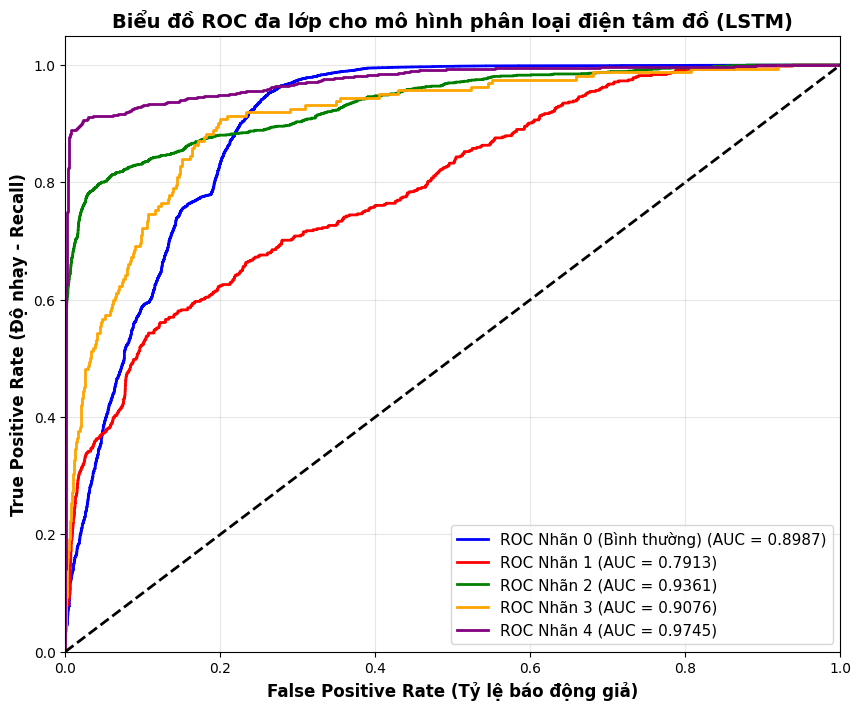

In [11]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("Đang quét tập Test để thu thập xác suất dự đoán...")

model1.eval()

all_targets = []
all_probs = [] # Mảng mới để lưu xác suất thay vì nhãn

with torch.no_grad():
    for batch_X, batch_y in test_load:
        batch_X = batch_X.to(device)
        batch_y = batch_y.long().to(device)
        
        outputs = model1(batch_X)
        
        # SỬ DỤNG SOFTMAX ĐỂ LẤY XÁC SUẤT (Từ 0.0 đến 1.0)
        probs = F.softmax(outputs, dim=1)
        
        all_targets.extend(batch_y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_true_np = np.array(all_targets)
y_probs_np = np.array(all_probs)

# 1. Chuyển đổi nhãn thật sang định dạng One-Hot (ví dụ: Nhãn 2 -> [0, 0, 1, 0, 0])
n_classes = 5
y_true_bin = label_binarize(y_true_np, classes=[0, 1, 2, 3, 4])

# 2. Khởi tạo biểu đồ Matplotlib
plt.figure(figsize=(10, 8))

# Cài đặt màu và tên cho 5 nhãn
colors = ['blue', 'red', 'green', 'orange', 'purple']
class_names = ['Nhãn 0 (Bình thường)', 'Nhãn 1', 'Nhãn 2', 'Nhãn 3', 'Nhãn 4']

# 3. Dùng vòng lặp để tính và vẽ đường ROC cho từng nhãn
for i in range(n_classes):
    # Tính FPR (Trục X) và TPR (Trục Y)
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_np[:, i])
    
    # Tính diện tích AUC
    roc_auc = auc(fpr, tpr)
    
    # Vẽ đường cong
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc:.4f})')

# 4. Vẽ đường chéo đứt nét (Baseline - Ngưỡng của một mô hình đoán mò, AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# 5. Căn chỉnh thẩm mỹ cho biểu đồ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Tỷ lệ báo động giả)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Độ nhạy - Recall)', fontsize=12, fontweight='bold')
plt.title('Biểu đồ ROC đa lớp cho mô hình phân loại điện tâm đồ (LSTM)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

# Xuất ảnh
plt.show()

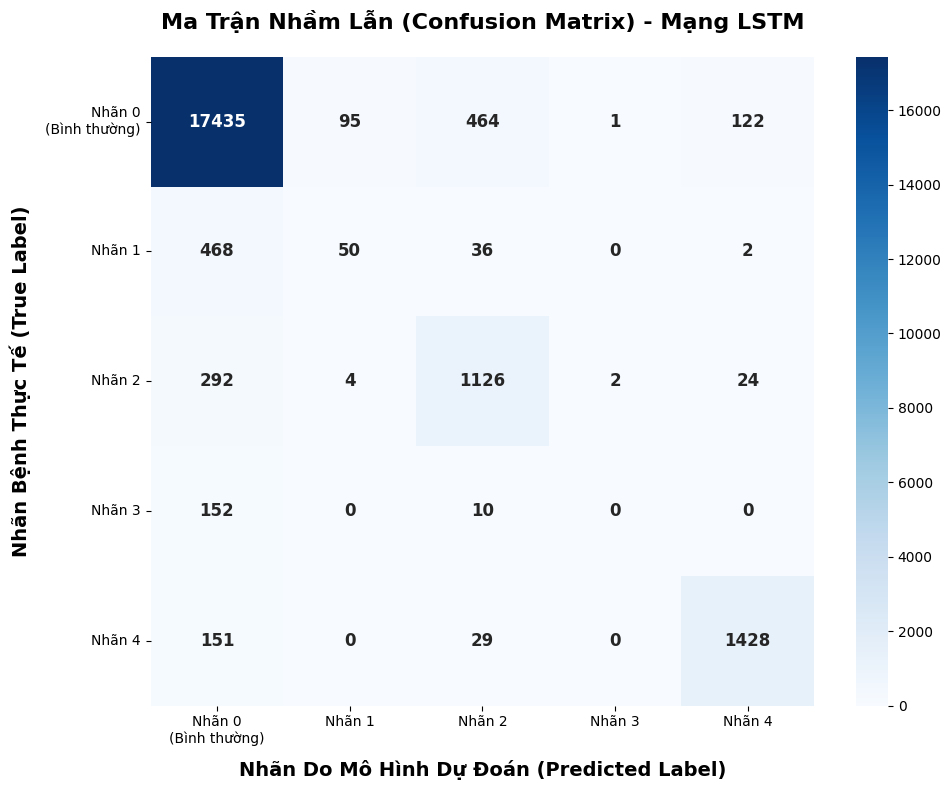

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Chuyển đổi mảng xác suất (từ bước vẽ ROC) thành nhãn dự đoán
# Lấy vị trí (index) có xác suất cao nhất làm kết quả dự đoán
y_pred_np = np.argmax(y_probs_np, axis=1)

# 2. Tính toán Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true_np, y_pred_np)

# 3. Khởi tạo khung biểu đồ
plt.figure(figsize=(10, 8))
class_names = ['Nhãn 0\n(Bình thường)', 'Nhãn 1', 'Nhãn 2', 'Nhãn 3', 'Nhãn 4']

# 4. Vẽ Heatmap bằng Seaborn
# Tham số cmap='Blues' tạo dải màu xanh chuyên nghiệp (đậm = nhiều, nhạt = ít)
# Tham số fmt='d' ép kiểu hiển thị là số nguyên (không có số thập phân)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12, "weight": "bold"})

# 5. Căn chỉnh thẩm mỹ cho dễ nhìn
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix) - Mạng LSTM', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nhãn Do Mô Hình Dự Đoán (Predicted Label)', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Nhãn Bệnh Thực Tế (True Label)', fontsize=14, fontweight='bold', labelpad=10)

# Xoay chữ ở trục X để không bị đè lên nhau
plt.xticks(rotation=0) 
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()